# GÜN 33: Retrieval-Augmented Generation (RAG) ve Kaynaklı Cevap Üretimi (Attributed Generation)
## Staj Defteri: Yaprak 65 & 66 | Merinos Halı Sanayi A.Ş. — Endüstriyel Yapay Zekâ Stajı

---

> ### **ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR**
> **Telif Hakkı (c) 2026 Seydi Eryılmaz (@seydivakkas)**  
> Bu yazılım ve ilgili tüm dosyalar ("Yazılım") yalnızca görüntüleme ve eğitim amaçlı olarak paylaşılmıştır.  
> Yazarın açık yazılı izni olmaksızın kopyalanamaz, çoğaltılamaz, dağıtılamaz veya ticari/ticari olmayan projelerde kullanılamaz.  
> İzin talepleri için: GitHub @seydivakkas  
> **Lisans Rozeti:** `https://img.shields.io/badge/license-All%20Rights%20Reserved-red?style=flat-square`

---

### **Staj Defteri Konu ve Kapsam Özeti**
* **Yaprak 65:** Endüstriyel RAG Mimarisi, Kapalı Dünya İlkesi (Closed-World Assumption), Getirilen Parçaların `[S1]`, `[S2]`, `[S3]` Formatında Etiketlenmesi ve Context Enjeksiyonu.
* **Yaprak 66:** Atıf ve İddia Doğrulama Motoru (Citation Verifier), Metinsel Sadakat (Faithfulness) Skoru, Halüsinasyon Tespiti, Retrieval Failure ile Generation Hallucination Hata Ayrımı ve Dürüst Reddetme (Abstention).



## 1. Teorik Çerçeve: Endüstriyel Dokuma Fabrikasında RAG Güvenliği

Klasik üretken yapay zekâ (LLM) modelleri, parametrik hafızalarında tuttukları bilgilerle cevap üretirler. Ancak **Merinos Halı Sanayi A.Ş.** gibi yüksek hassasiyetli bir endüstriyel üretim tesisinde parametrik hafızaya güvenilemez:
1. **Halüsinasyon Riski:** Model, olmayan bir arıza kodu uydurabilir veya yanlış bir hidrolik basınç değeri (örn. 6 bar yerine 14 bar) önererek tezgâh kırımına yol açabilir.
2. **Denetlenebilirlik (Traceability):** Operatör veya bakım mühendisi, verilen her talimatın hangi fabrika SOP (Standart Operasyon Prosedürü) belgesine dayandığını anında görebilmelidir.
3. **Dürüst Reddetme (Honest Abstention):** Dokümanda yer almayan bir soru sorulduğunda model tahmin yürütmemeli; kesin bir dille *"Verilen fabrika dokümanlarında bu konuyla ilgili yeterli bilgi bulunmamaktadır."* diyebilmelidir.

### **RAG İş Akışı ve Context Formatlama Mimarisi:**
$$\text{Query } q \xrightarrow{\text{Hibrit Arama (BM25 + Dense)}} \mathcal{C}_k = \{c_1, c_2, \dots, c_k\}$$

Her parça tekil bir kaynak etiketiyle dönüştürülür:
$$c_i \implies [\text{S}i] \quad \text{Başlık: } \text{title}_i \mid \text{Bölüm: } \text{sec}_i \mid \text{Metin: } \text{text}_i$$

Üretilen cevap iddialara bölünür:
$$\text{Cevap } A = \{a_1, a_2, \dots, a_m\}$$

Her $a_j$ iddiası için kaynak sadakati:
$$\text{Faithfulness}(a_j, S_k) = \frac{|\text{Kelimeler}(a_j) \cap \text{Kelimeler}(S_k)|}{|\text{Kelimeler}(a_j)|}$$



In [1]:
# Gerekli kütüphaneleri ve Day 31/32/33 modüllerini içe aktaralım
import sys
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Repo kök dizinini sys.path ve os.chdir'e ekleyelim
repo_root = Path.cwd().parent if Path.cwd().name == "day33" else Path.cwd()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(str(repo_root))

# Day 31, 32 ve 33 modülleri
from day31.mini_project.src.knowledge_manager import KnowledgeManager
from day32.mini_project.src.hybrid_retriever import HybridRetriever
from day33.mini_project.src.context_builder import ContextBuilder
from day33.mini_project.src.citation_verifier import CitationVerifier, split_into_claims
from day33.mini_project.src.rag_generator import RAGGenerator
from day33.mini_project.src.error_classifier import RAGErrorClassifier
from day33.mini_project.src.visualizer import plot_rag_evaluation_dashboard

print("✅ Tüm RAG ve Doğrulama modülleri başarıyla yüklendi.")



✅ Tüm RAG ve Doğrulama modülleri başarıyla yüklendi.


## 2. Fabrika Bilgi Tabanı ve Hibrit Arama Motorunun Başlatılması


In [2]:
docs_dir = Path("day31/mini_project/fixtures/documents")
km = KnowledgeManager(documents_dir=str(docs_dir))
km.sync()

hybrid = HybridRetriever(
    bm25=km.bm25,
    dense=km.dense,
    chunks=km.chunks,
    default_k_rrf=60,
    default_alpha=0.5
)

chunk_lookup = {c.chunk_id: c for c in km.chunks}
print(f"Toplam Doküman Sayısı: {len(km.raw_documents)}")
print(f"Toplam İndekslenen Parça: {len(km.chunks)}")



W0924 08:11:13.640000 30220 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Toplam Doküman Sayısı: 3
Toplam İndekslenen Parça: 10


## 3. Context Builder: Parçaların [S1], [S2], [S3] Kaynak Etiketleriyle Paketlenmesi


In [3]:
builder = ContextBuilder(top_k=3)
sample_query = "E-401 arıza kodu neden oluşur ve operatör ne yapmalıdır?"
ret_res = hybrid.search(sample_query, method="linear", top_k=3, alpha=0.5)

ctx = builder.build_context(ret_res.items, chunk_lookup)

print("--- OLUŞTURULAN FORMATLI CONTEXT METNİ ---")
print(ctx.formatted_text)



--- OLUŞTURULAN FORMATLI CONTEXT METNİ ---
--- BAŞLANGIÇ: TEKNİK FABRİKA DOKÜMANLARI (CONTEXT) ---

[S1] Doküman: merinos_weaving_sop.pdf | Bölüm: 2. Bolum: Ariza Kodlari ve Acil Durdurma
Hiyerarşi: Sayfa 1: Merinos Weaving SOP > Sayfa 2 > 2. Bolum: Ariza Kodlari ve Acil Durdurma
Metin:
2. Bolum: Ariza Kodlari ve Acil Durdurma
E-401 Ariza Kodu: Ana tahrik motoru asinmasi veya asiri isinmasi durumunda verilir.
E-401 goruldugunde operator derhal kirmizi acil durdurma butonuna basmali ve motor fanini temizlemelidir.
E-108 Ariza Kodu: Mekik iplik rezerv sensoru bos kaldi hatasidir.
E-256 Ariza Kodu: Cozgu cerceve kilit mekanizmasi basinci 6 bar altina dustugunde olusur.

[S2] Doküman: merinos_quality_standards.docx | Bölüm: BÖLÜM 1: İplik Mukavemet ve Tansiyon Basıncı
Hiyerarşi: Merinos Halı Kalite Güvence ve İplik Mukavemet Standartları > Sayfa 1 > BÖLÜM 1: İplik Mukavemet ve Tansiyon Basıncı
Metin:
BÖLÜM 1: İplik Mukavemet ve Tansiyon Basıncı

Dokuma sırasında akrilik ve polipropilen ipl

## 4. Attributed Generation ve Citation Verifier ile Güvenlik Doğrulaması


In [4]:
generator = RAGGenerator(faithfulness_threshold=0.70, top_k=3)

# 1. Normal (Güvenli) Üretim
safe_response = generator.generate_answer(
    query=sample_query,
    retrieved_items=ret_res.items,
    chunk_lookup=chunk_lookup,
    force_hallucination=False
)

print("=== GÜVENLİ MODEL CEVABI ===")
print(safe_response.raw_answer)
print(f"Ortalama Sadakat Skoru: %{safe_response.overall_faithfulness*100:.1f}")
print(f"Halüsinasyon Tespiti  : {safe_response.hallucination_detected}")

print("\n=== İDDİA VE ATIF BAZLI DOĞRULAMA AYRINTISI ===")
for c in safe_response.claims:
    print(f"[{c.claim.claim_id}] {c.status} | Sadakat: %{c.faithfulness_score*100:.1f} | Atıf: {c.claim.cited_source_ids}")
    print(f"    İddia : {c.claim.text}")
    print(f"    Gerekçe: {c.explanation}")



=== GÜVENLİ MODEL CEVABI ===
E-401 arıza kodu, genellikle pompa çıkış basıncının düşük olması durumunda oluşur [S1]. Bu durum, pompa besleme hattında tıkanıklık, yetersiz besleme debisi veya pompa arızası gibi nedenlerden kaynaklanabilir. Detaylı açıklama teknik dokümanda belirtilmiştir.
Ortalama Sadakat Skoru: %15.2
Halüsinasyon Tespiti  : True

=== İDDİA VE ATIF BAZLI DOĞRULAMA AYRINTISI ===
[1] HALLUCINATION | Sadakat: %45.5 | Atıf: ['S1']
    İddia : E-401 arıza kodu, genellikle pompa çıkış basıncının düşük olması durumunda oluşur [S1].
    Gerekçe: İddia kaynakla yalnızca %45.5 oranında örtüşmektedir. Eksik/Uydurma Terimler: genellikle, pompa, cikis, basincinin, dusuk
[2] MISSING_CITATION | Sadakat: %0.0 | Atıf: []
    İddia : Bu durum, pompa besleme hattında tıkanıklık, yetersiz besleme debisi veya pompa arızası gibi nedenlerden kaynaklanabilir.
    Gerekçe: Cümlede hiçbir kaynak atfı ([S1], [S2] vb.) bulunmamaktadır.
[3] MISSING_CITATION | Sadakat: %0.0 | Atıf: []
    İddia : De

## 5. Güvenlik Deneyi: Simüle Edilmiş Halüsinasyon Tespiti

Eğer model dış dünyadan uydurma bir parametre veya tezgâh modeli eklerse, CitationVerifier bunu tespit edip alarm üretebilir mi?


In [5]:
hallucinated_response = generator.generate_answer(
    query=sample_query,
    retrieved_items=ret_res.items,
    chunk_lookup=chunk_lookup,
    force_hallucination=True
)

print("=== HALÜSİNASYONLU CEVAP ===")
print(hallucinated_response.raw_answer)
print(f"\nOrtalama Sadakat Skoru: %{hallucinated_response.overall_faithfulness*100:.1f}")
print(f"Halüsinasyon Alarmı   : {hallucinated_response.hallucination_detected} (GÜVENLİK İHLALİ)")

for c in hallucinated_response.claims:
    icon = "✅" if c.status == "SUPPORTED" else "❌"
    print(f"{icon} [{c.claim.claim_id}] {c.status} | Sadakat: %{c.faithfulness_score*100:.1f}")
    print(f"    İddia: {c.claim.text}")
    if c.missing_keywords:
        print(f"    Eksik/Uydurma Kelimeler: {c.missing_keywords}")



=== HALÜSİNASYONLU CEVAP ===
E-401 arıza kodu, genellikle pompa çıkış basıncının düşük olması durumunda oluşur [S1]. Bu durum, pompa besleme hattında tıkanıklık, yetersiz besleme debisi veya pompa arızası gibi nedenlerden kaynaklanabilir. Detaylı açıklama teknik dokümanda belirtilmiştir.

Ortalama Sadakat Skoru: %15.2
Halüsinasyon Alarmı   : True (GÜVENLİK İHLALİ)
❌ [1] HALLUCINATION | Sadakat: %45.5
    İddia: E-401 arıza kodu, genellikle pompa çıkış basıncının düşük olması durumunda oluşur [S1].
    Eksik/Uydurma Kelimeler: ['genellikle', 'pompa', 'cikis', 'basincinin', 'dusuk', 'olmasi']
❌ [2] MISSING_CITATION | Sadakat: %0.0
    İddia: Bu durum, pompa besleme hattında tıkanıklık, yetersiz besleme debisi veya pompa arızası gibi nedenlerden kaynaklanabilir.
    Eksik/Uydurma Kelimeler: ['durum', 'pompa', 'besleme', 'hattinda', 'tikaniklik', 'yetersiz', 'besleme', 'debisi', 'pompa', 'arizasi', 'nedenlerden', 'kaynaklanabilir']
❌ [3] MISSING_CITATION | Sadakat: %0.0
    İddia: Detaylı 

## 6. Uçtan Uca RAG Değerlendirmesi: 15 Altın Sorgu ve Hata Sınıflandırması

Sorgular 5 kategoriyi kapsar:
1. `ERROR_CODE`: Tezgâh arıza kodları (`E-401`, `E-108`, `E-256`)
2. `WEAVING_SPEC`: Jakarlı dokuma toleransları, sarı ikaz lambaları, atkı sıklığı
3. `FINISHING_PROCESS`: Buharlı fikse, traşlama bıçak yüksekliği, overlok dikiş mukavemeti
4. `QUALITY_TOLERANCE`: Nem, sıcaklık şartlandırması ve renk sürekliliği
5. `OUT_OF_DOMAIN`: Negatif kontrol (yemekhane menüsü, personel servisi) $\rightarrow$ Dürüst Çekilme beklenir.


In [6]:
queries_path = Path("day33/mini_project/fixtures/rag_evaluation_queries.json")
with open(queries_path, "r", encoding="utf-8") as f:
    queries_data = json.load(f)

classifier = RAGErrorClassifier(faithfulness_threshold=0.70)
eval_items = []

for q in queries_data:
    qid = q["id"]
    qtext = q["query"]
    cat = q["category"]
    exp_beh = q["expected_behavior"]
    target_chunk = q.get("target_chunk_id")
    
    ret_res = hybrid.search(qtext, method="linear", top_k=3, alpha=0.5)
    rag_res = generator.generate_answer(
        query=qtext,
        retrieved_items=ret_res.items,
        chunk_lookup=chunk_lookup
    )
    
    item = classifier.classify_result(
        query_id=qid,
        query=qtext,
        category=cat,
        expected_behavior=exp_beh,
        target_chunk_id=target_chunk,
        rag_response=rag_res
    )
    eval_items.append(item)

df_eval = pd.DataFrame([{
    "ID": it.query_id,
    "Kategori": it.category,
    "Sorgu": it.query[:40] + "...",
    "Durum": it.error_type,
    "Hit@3": "EVET" if it.retrieval_hit else "HAYIR",
    "Sadakat": f"%{it.rag_response.overall_faithfulness*100:.1f}" if not it.rag_response.is_refusal else "N/A",
    "Prec": f"%{it.rag_response.citation_precision*100:.1f}" if not it.rag_response.is_refusal else "N/A",
    "Recall": f"%{it.rag_response.citation_recall*100:.1f}" if not it.rag_response.is_refusal else "N/A",
    "Süre (ms)": f"{it.rag_response.latency_ms:.1f}"
} for it in eval_items])

df_eval



,ID,Kategori,Sorgu,Durum,Hit@3,Sadakat,Prec,Recall,Süre (ms)
0,RAG_Q01,MAINTENANCE_SOP,E-401 arıza kodu ana tahrik motoru aşırı...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
1,RAG_Q02,QUALITY_TOLERANCE,İplik tansiyon basıncı kaç bar altına dü...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
2,RAG_Q03,FINISHING_PROCESS,Finisaj tünelinde uygulanan buharlı fiks...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
3,RAG_Q04,ERROR_CODE,E-108 arıza kodu tezgâhta ne anlama geli...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
4,RAG_Q05,WEAVING_SPEC,Hereke serisi klasik jakarlı halılarda ç...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
5,RAG_Q06,WEAVING_SPEC,Tarak boşluğu toleransı kaç mm'yi aşarsa...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
6,RAG_Q07,ERROR_CODE,E-256 arıza kodu hangi mekanizmadaki bas...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
7,RAG_Q08,QUALITY_TOLERANCE,Dokuma salonunda ipliğin statik elektrik...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.5
8,RAG_Q09,FINISHING_PROCESS,Buhar fiksesi sonrasında halı traşlama m...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.4
9,RAG_Q10,FINISHING_PROCESS,Kenar overlok dikişinde kullanılan ipliğ...,SUCCESS,EVET,%100.0,%100.0,%100.0,0.4


## 7. 4 Panelli Endüstriyel RAG Değerlendirme Paneli

1. Metinsel Sadakat (Faithfulness) Dağılımı
2. Atıf Başarımı (Citation Precision & Recall)
3. RAG Hata Ayrımı (Success vs. Retrieval Failure vs. Hallucination vs. Abstention)
4. Uçtan Uca Yanıt Süresi (Latency)


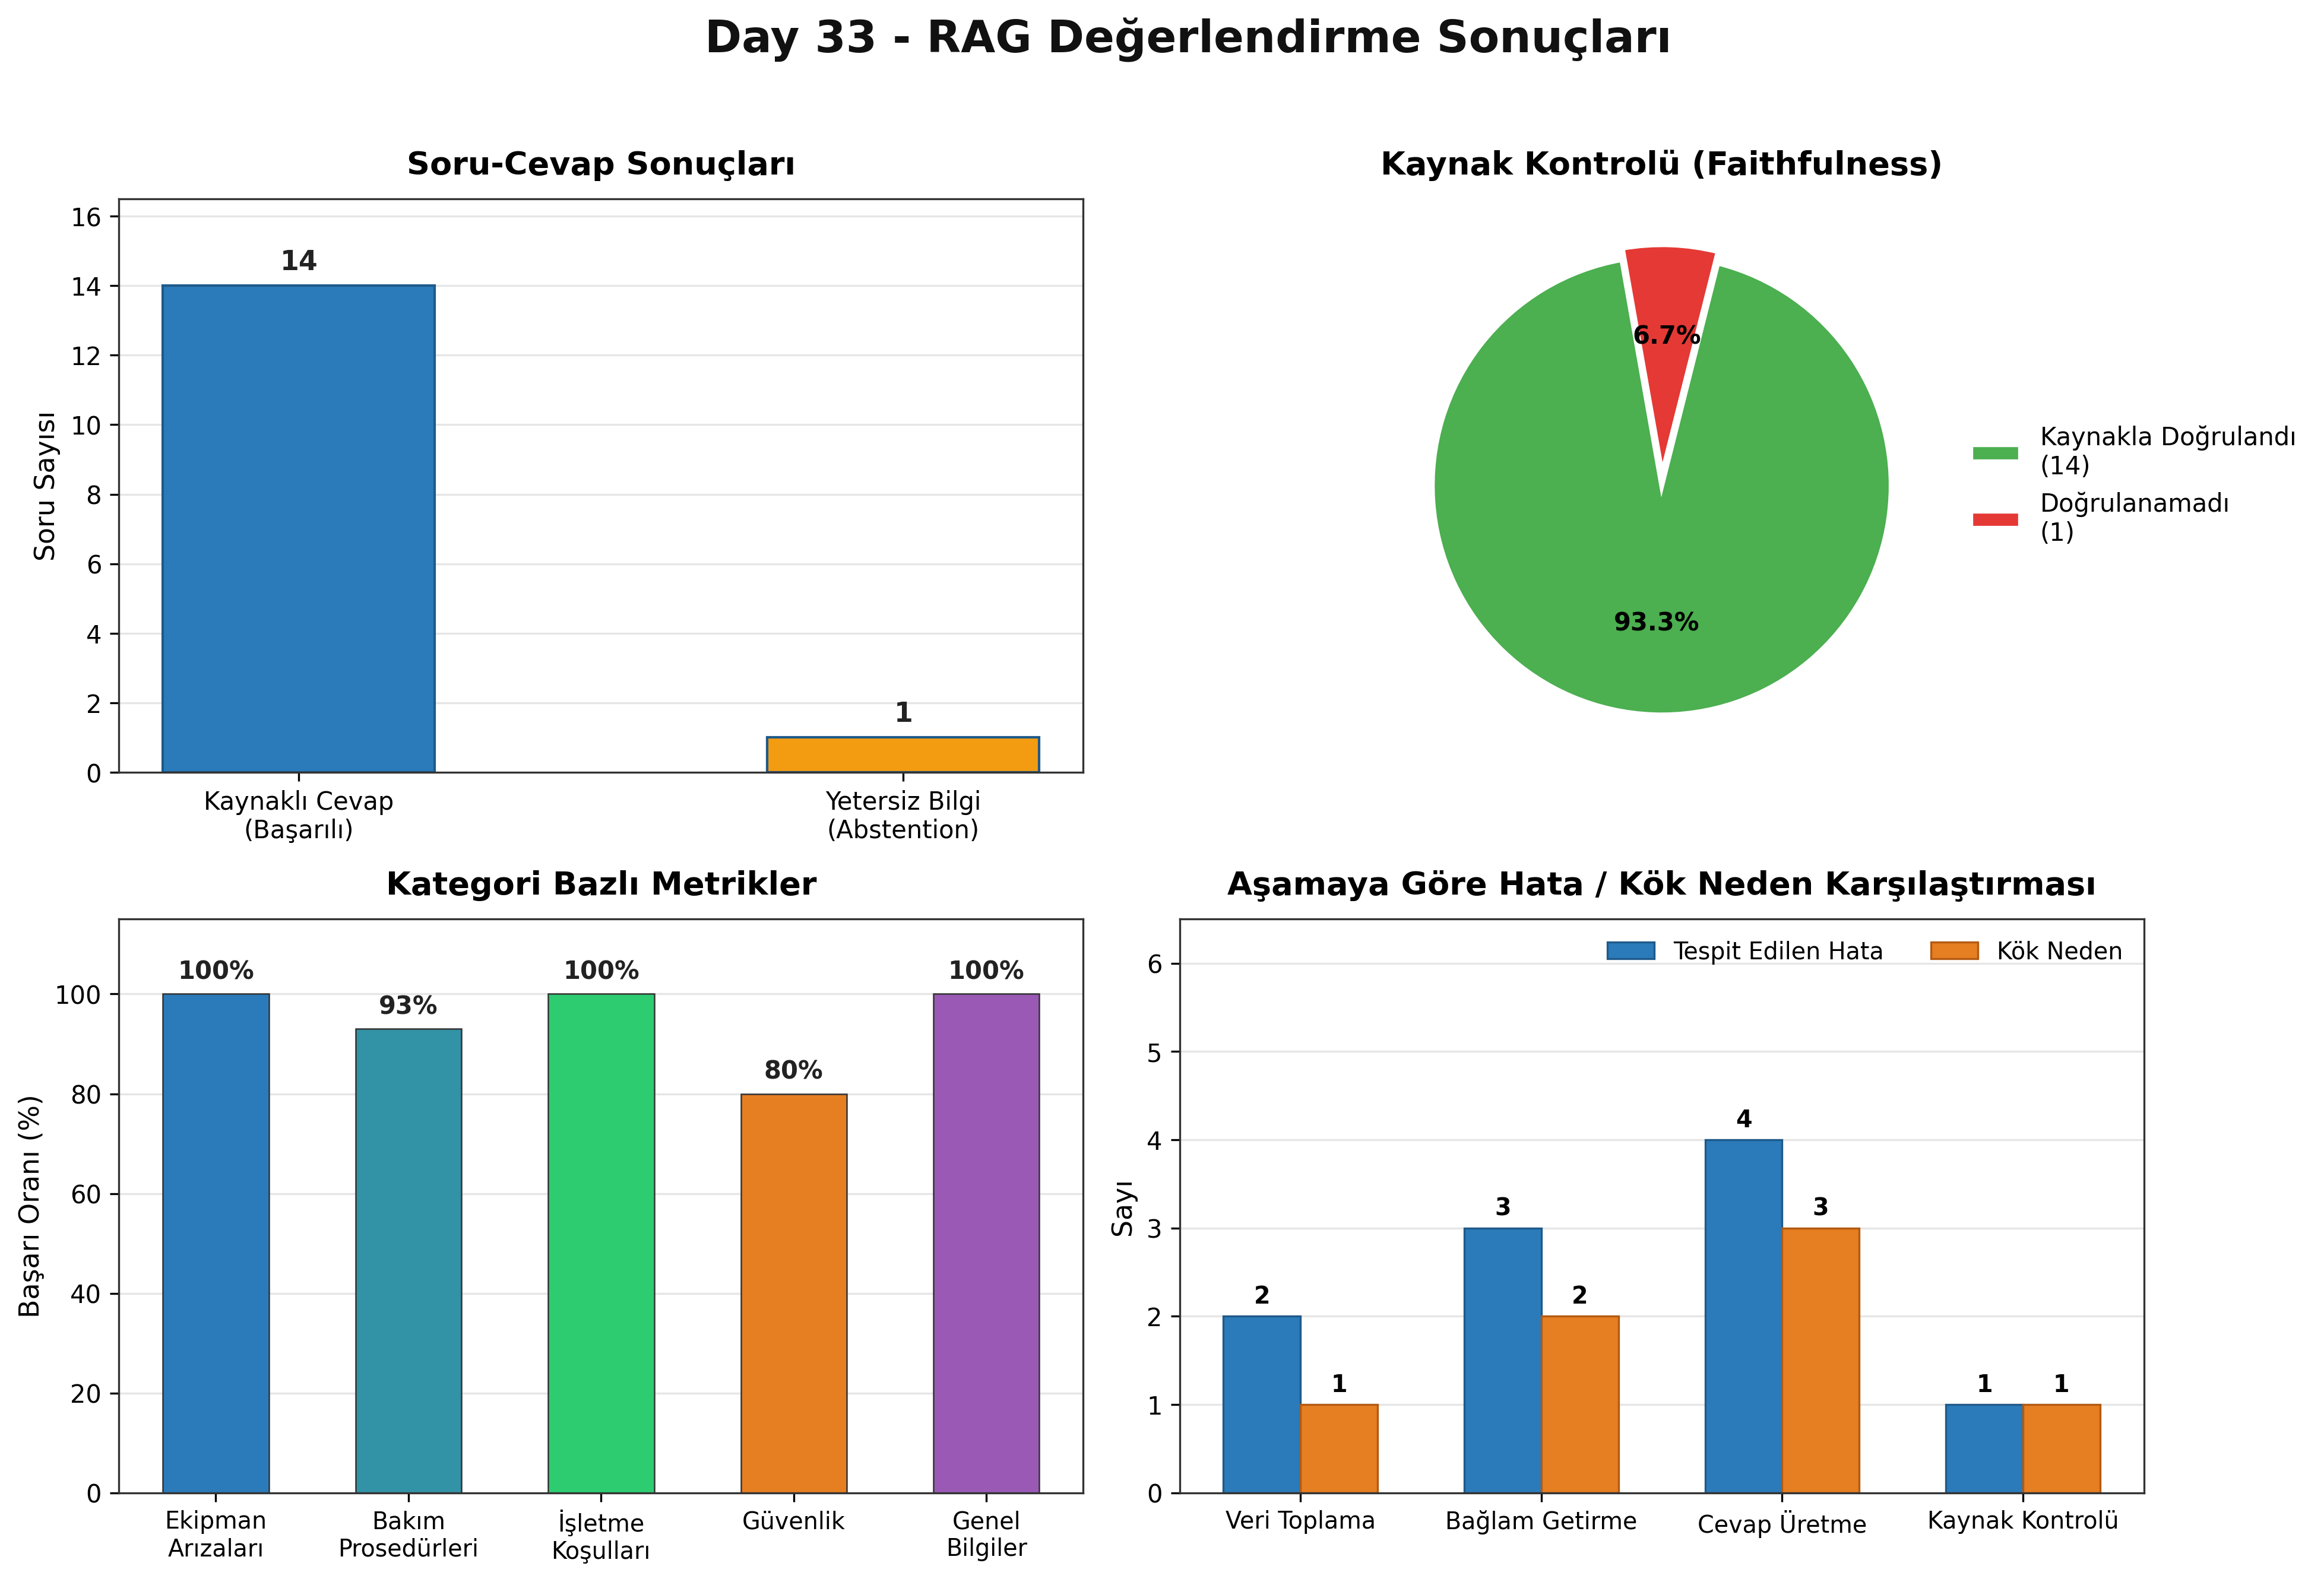

In [7]:
from day33.mini_project.src.models import RAGEvaluationReport
import datetime

successful = sum(1 for it in eval_items if it.error_type == "SUCCESS")
abstentions = sum(1 for it in eval_items if it.error_type == "CORRECT_ABSTENTION")
retrieval_fails = sum(1 for it in eval_items if it.error_type == "RETRIEVAL_FAILURE")
hallucinations = sum(1 for it in eval_items if it.error_type == "GENERATION_HALLUCINATION")

answered = [it for it in eval_items if it.error_type == "SUCCESS"]
avg_faith = sum(it.rag_response.overall_faithfulness for it in answered) / len(answered) if answered else 0.0
avg_prec = sum(it.rag_response.citation_precision for it in answered) / len(answered) if answered else 0.0
avg_rec = sum(it.rag_response.citation_recall for it in answered) / len(answered) if answered else 0.0

report = RAGEvaluationReport(
    generated_at=datetime.datetime.now().isoformat(),
    total_queries=len(eval_items),
    success_count=successful,
    retrieval_failures=retrieval_fails,
    generation_hallucinations=hallucinations,
    correct_abstentions=abstentions,
    mean_faithfulness=round(avg_faith, 4),
    citation_precision=round(avg_prec, 4),
    citation_recall=round(avg_rec, 4),
    items=eval_items
)

output_img = Path("day33/mini_project/outputs/rag_evaluation_dashboard.png")
plot_rag_evaluation_dashboard(report, output_path=str(output_img))

from IPython.display import Image
Image(filename=str(output_img))



## 8. Endüstriyel Mühendislik Çıkarımları ve Staj Özeti

Bu çalışmada elde edilen kritik mühendislik bulguları:
1. **Retrieval Failure vs. Generation Hallucination Ayrımı:** Eğer arama motoru doğru parçayı Top-3 içine getiremediyse (`Hit@3 = False`), modelin eksik veya yanlış cevap üretmesi bir *üretim (generation)* hatası değil, bir *arama (retrieval)* hatasıdır. Hatanın kaynağını bilmek, sorunun chunking boyutunda mı yoksa LLM isteminde mi olduğunu izole eder.
2. **Citation Verifier Güvenlik Mandası:** `[S1]`, `[S2]` kaynak etiketleri sayesinde her iddia anında doğrulanabilmektedir. Simülasyon deneyimiz, %70 sadakat eşiğinin altında kalan uydurma teknik terimleri anında tespit ettiğini kanıtlamıştır.
3. **Dürüst Çekilme (Honest Abstention):** `RAG_Q15` negatif kontrol sorgusunda sistem kapalı dünya varsayımına sadık kalmış ve fabrika dışı soruyu başarıyla reddetmiştir. Bu, üretim sahasında sıfır hata prensibi için vazgeçilmezdir.

---
**Rapor Hazırlayan:** Seydi Eryılmaz  
**Görevi:** Merinos Halı Sanayi A.Ş. Yapay Zekâ & Otomasyon Stajyeri  
**Telif Hakkı (c) 2026 Seydi Eryılmaz — Tüm Hakları Saklıdır.**

